# Mathematical Modeling

------------

## A. Set up card model

Enumerated attributes:

* Color
    * Red
    * Purple
    * Green
* Count
    * 1
    * 2
    * 3
* Fill
    * Solid
    * Striped
    * Open
* Shape
    * Capsule
    * Diamond
    * Squiggle

I think the best way is to number them instead of keeping string lables, and this is for two reasons. 

1. Pragmatic: indexing arrays is easy with numbers.
2. Semantic: All attributes are equal in function and importance.

In [1]:
import numpy as np
import random
from pprint import pprint
from itertools import combinations
from tqdm import tqdm
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from datetime import datetime


from visualize_cards import Card

1. establish the cardspace

In [2]:
size = 3
grid = np.array([[[[i for i in range(size)] for _ in range(size)] for _ in range(size)] for _ in range(size)])
grid

array([[[[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]]],


       [[[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]]],


       [[[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]],

        [[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]]]])

2. Function to detect if any set of coords is a set

There are only three states, so no need to get fancy with the linalg.

In [18]:
# def check_colinearity(a, b, c):
#     lengths = [len(set([x[dim] for x in (a, b, c)])) for dim in range(4)]
#     if 2 in lengths:
#         return False, 0
#     else:
#         return True, lengths.count(1)

check_hashmap =  {frozenset({0}), frozenset({1}), frozenset({2}), frozenset({0, 1, 2})}

def hash_colinearity(a, b, c):
    for i in range(4):
        if frozenset((a[i], b[i], c[i])) in check_hashmap:
            continue
        else:
            return False
    return True

In [19]:
tests = [[[0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 0, 2]], 
         [[0, 0, 0, 0], [0, 0, 0, 1], [0, 0, 0, 1]],
         [[1, 1, 1, 1], [0, 0, 0, 0], [2, 2, 2, 2]],
         [[0, 1, 2, 0], [1, 1, 2, 1], [2, 1, 2, 2]], 
         [[0, 1, 2, 0], [1, 1, 2, 1], [2, 2, 2, 2]]]

answers = [True, False, True, True, False]

for t, a in zip(tests, answers):
    # if (outcome := check_colinearity(*t))[0] == a:
    if (outcome := hash_colinearity(*t)) == a:
        print('pass', outcome)
    else:
        print('fail', outcome)

pass True
pass False
pass True
pass True
pass False


## B. How many sets of 12 don't have any sets?

for any given 3 cards amongst any given 12 cards, 

In [7]:
choices = [0, 1, 2]

for _ in range(4):
    random_dims = [random.choice(choices) for _ in range(4)]
    print(random_dims)
    random_card = Card(random_dims)
    pprint(random_card.__dict__)
    
    for i in random_card.vis:
        print(i)

[1, 0, 1, 0]
{'color': 'red',
 'fill': 'stripe',
 'number': 2,
 'shape': 'diamond',
 'vis': ['\x1b┌───┐\x1b',
         '\x1b│<▥>│\x1b',
         '\x1b│   │\x1b',
         '\x1b│<▥>│\x1b',
         '\x1b└───┘\x1b']}
┌───┐
│<▥>│
│   │
│<▥>│
└───┘
[1, 1, 1, 0]
{'color': 'purple',
 'fill': 'stripe',
 'number': 2,
 'shape': 'diamond',
 'vis': ['\x1b┌───┐\x1b',
         '\x1b│<▥>│\x1b',
         '\x1b│   │\x1b',
         '\x1b│<▥>│\x1b',
         '\x1b└───┘\x1b']}
┌───┐
│<▥>│
│   │
│<▥>│
└───┘
[2, 1, 0, 2]
{'color': 'purple',
 'fill': 'empty',
 'number': 3,
 'shape': 'capsule',
 'vis': ['\x1b┌───┐\x1b',
         '\x1b│(☐)│\x1b',
         '\x1b│(☐)│\x1b',
         '\x1b│(☐)│\x1b',
         '\x1b└───┘\x1b']}
┌───┐
│(☐)│
│(☐)│
│(☐)│
└───┘
[2, 1, 1, 1]
{'color': 'purple',
 'fill': 'stripe',
 'number': 3,
 'shape': 'squiggle',
 'vis': ['\x1b┌───┐\x1b',
         '\x1b│╔▥╝│\x1b',
         '\x1b│╔▥╝│\x1b',
         '\x1b│╔▥╝│\x1b',
         '\x1b└───┘\x1b']}
┌───┐
│╔▥╝│
│╔▥╝│
│╔▥╝│
└───┘


In [8]:
def display_grid(twelve):
    for row_idxs in [list(range(4)), list(range(4, 8)), list(range(8, 12))]:
        # print(row_idxs)
        print('' + '   '.join([f'{i}'.rjust(3) for i in row_idxs]))
        cards = list(map(lambda x: Card(twelve[x]), row_idxs))
        for line in range(5):
            line = [f'{card.vis[line]} ' for card in cards]
            print(''.join(line))

In [14]:
def count_sets(twelve):
    sets = 0
    for comb in combinations(range(12), 3):
        cards = [twelve[c] for c in comb]
        set_found = hash_colinearity(*cards)
        if set_found:
            sets += 1
    return sets

In [10]:
random_12 = {j: [random.choice(choices) for _ in range(4)] for j in range(12)}
# pprint(random_12)

display_grid(random_12)

counts = count_sets(random_12)
print(f'\n{counts} Sets Found:')
for comb in combinations(range(12), 3):
    cards = [random_12[c] for c in comb]
    set_found, count = check_colinearity(*cards)
    if set_found:
        print(comb, count)


  0     1     2     3
┌───┐ ┌───┐ ┌───┐ ┌───┐ 
│<■>│ │<☐>│ │<☐>│ │   │ 
│   │ │<☐>│ │<☐>│ │(☐)│ 
│<■>│ │<☐>│ │<☐>│ │   │ 
└───┘ └───┘ └───┘ └───┘ 
  4     5     6     7
┌───┐ ┌───┐ ┌───┐ ┌───┐ 
│╔▥╝│ │   │ │   │ │╔☐╝│ 
│   │ │(■)│ │<▥>│ │╔☐╝│ 
│╔▥╝│ │   │ │   │ │╔☐╝│ 
└───┘ └───┘ └───┘ └───┘ 
  8     9    10    11
┌───┐ ┌───┐ ┌───┐ ┌───┐ 
│   │ │<■>│ │╔■╝│ │╔▥╝│ 
│(■)│ │   │ │   │ │   │ 
│   │ │<■>│ │╔■╝│ │╔▥╝│ 
└───┘ └───┘ └───┘ └───┘ 

0 Sets Found:


I wonder how low it will take to iterate through every set of 12... 

In [20]:
total_boards = 707_243_201_847
every_possible_card = [] #81 cards, not too much RAM
for a in range(3):
    for b in range(3):
        for c in range(3):
            for d in range(3):
                every_possible_card.append([a, b, c, d])

start_time = datetime.now()
set_counter = defaultdict(int)
trials = int(1e6)
for _ in tqdm(range(trials)):
    combo = random.sample(every_possible_card, 12)
# for combo in tqdm(combinations(every_possible_card, 12)):
    n_sets = count_sets(combo)
    set_counter[n_sets] += 1
    # if counter % int(1e9) == 0:
    #     print(f'{100*(counter/total_boards)}%' )
taken_time = datetime.now() - start_time

outcomes = {k: 100*(v/trials) for k, v in set_counter.items()}
pprint(outcomes)


sampled_pct = trials / total_boards

print('PURE PYTHON IMPLEMENTATION:')
print(f'Tested {sampled_pct*100}% of the total space, taking {taken_time.total_seconds()} seconds.')
print(f'At this rate, sampling the full space would take {(taken_time.total_seconds() / sampled_pct) / (365.2425 * 24 * 60 * 60)} years.')

100%|██████████| 1000000/1000000 [01:29<00:00, 11200.67it/s]

{0: 3.2365,
 1: 14.5278,
 2: 26.137300000000003,
 3: 27.214100000000002,
 4: 18.006700000000002,
 5: 8.010399999999999,
 6: 2.3078000000000003,
 7: 0.47540000000000004,
 8: 0.0675,
 9: 0.0137,
 10: 0.0028}
PURE PYTHON IMPLEMENTATION:
Tested 0.00014139407736807528% of the total space, taking 89.282351 seconds.
At this rate, sampling the full space would take 2.0009643450250745 years.


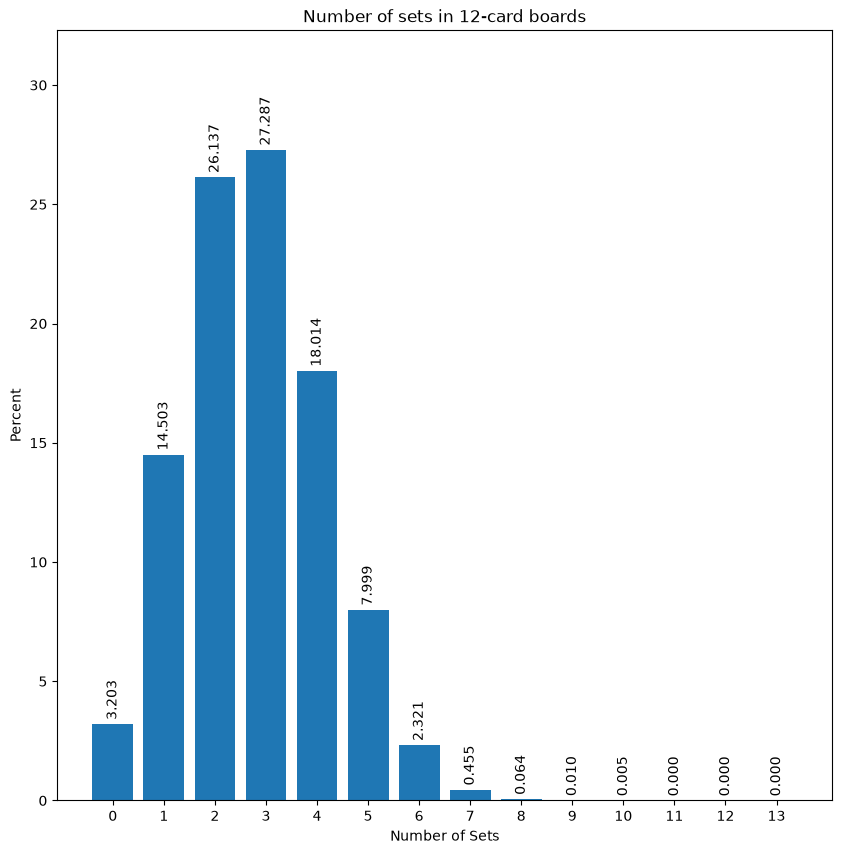

In [30]:
# sort by number of sets
items = sorted(outcomes.items())

labels = np.array([k for k, v in items], dtype=float)
sizes = np.array([v for k, v in items], dtype=float)

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.bar(labels, sizes)

# labels on each bar
ax.bar_label(bars, labels=[f"{v:.3f}" for v in sizes], padding=3, rotation=90)
ax.set_ylim(0, max(sizes)+5)
ax.set_xticks(labels)
ax.set_title("Number of sets in 12-card boards")
ax.set_xlabel("Number of Sets")
ax.set_ylabel("Percent")

plt.show()

so of 12-card boards, there are about 3.2% of them will NOT have a single set. The peak is between 2-3 sets per 12-card board, 

Whaaat if I try it in C?

In [23]:
!gcc -O3 c_search_space.c -o c_search_space

total_boards = 707_243_201_847
trials = int(1e7)
board_size = 12

start_time = datetime.now()
!./c_search_space {trials} {board_size}
taken_time = datetime.now() - start_time

sampled_pct = trials / total_boards

print('CLANG IMPLEMENTATION:')
print(f'Tested {sampled_pct*100}% of the total space for board size {board_size}, taking {taken_time.total_seconds()} seconds.')
print(f'At this rate, sampling the full space would take {(taken_time.total_seconds() / sampled_pct) / (24 * 60 * 60)} days.')

5: 2252200
6: 3215074
7: 1974960
8: 1314820
9: 845464
10: 317898
11: 12600
12: 46152
13: 18240
14: 2592
CLANG IMPLEMENTATION:
Tested 0.0014139407736807527% of the total space for board size 12, taking 3.725471 seconds.
At this rate, sampling the full space would take 3.0495532852177605 days.


In [ ]:
byte_count = 707_243_201_847 * 12 * 4  #unique_boards * Cards per board * attributes per card
TB_count = byte_count/(1000**4)
print(f'Assuming a 4 byte int, the total search space would take {TB_count} TB')

Assuming a 4 byte int, the total search space woudld take 33.947673688656 TB


Okay this is kind of absurd. Is there a more performant way of checking for colinearity? 

a, b, and c, are arrays of 4 ints, e.g. [0, 1, 2, 0]

(all logic below is written in Python for readability)

#### 1. initial approach (pure python):
```
def check_colinearity(a, b, c):
    common_dims = [len(set([x[dim] for x in (a, b, c)])) for dim in range(4)]
    if 2 in lengths:
        return False, 0
    else:
        return True, common_dims.count(1)
```
I would like to keep the functionality of counting how many attributes are identical for all three sets, ideally.

#### 2. Current approach (C):
```
def c_colinearity(a, b, c):
    for i in range(4):
        if sum([a[i] + b[i] + c[i]]) % 3 == 0:
            continue
        else:
            return False
    return True
```
Elegant trick with checking for mod 3. 

#### 3. Hash approach: 
```
check_hashmap =  {frozenset({0}), frozenset({1}), frozenset({2}), frozenset({0, 1, 2})}

def hash_colinearity(a, b, c):
    for i in range(4):
        if frozenset((a[i], b[i], c[i])) in check_hashmap:
            continue
        else:
            return False
    return True
```
probably the fastest python way of doing it? This got me from a estimated 5.5 yrs to 2 years. 

#### 4. difference approach:

```
def c_colinearity(a, b, c):
    for i in range(4):
        sorted_vals = sorted(a[i], b[i], c[i]) #uses powersort? idk about sorting algos
        if sorted_vals[1] - sorted_vals[0] == sorted_vals[2] - sorted_vals[1]:
            continue
        else:
            return False
    return True
```
Would be flexible enough to account for values outside of (0, 1, 2), but that's not needed for this project. 

#### 5. array sum approach:

```
de arr_colinearity(a, b, c):
    common_attr = 0
    for i in range(4):
        idxs = [0, 0, 0]
        idxs[a[i]] = 1 ; idxs[b[i]] = 1 ; idxs[c[i]] = 1
        if sum(idxs) == 2:
            return False
        elif sum(idxs) == 1:
            common_attr += 1
    return True, common_attr
```

# C. How many 15-card boards don't have sets?

oh boy. Let's see how long combo(81, 15) takes. 

In [26]:
!gcc -O3 c_search_space.c -o c_search_space

total_boards = 707_243_201_847
trials = int(1e7)
board_size = 15

start_time = datetime.now()
!./c_search_space {trials} {board_size}
taken_time = datetime.now() - start_time

sampled_pct = trials / total_boards

print('CLANG IMPLEMENTATION:')
print(f'Tested {sampled_pct*100}% of the total space for board size {board_size}, taking {taken_time.total_seconds()} seconds.')
print(f'At this rate, sampling the full space would take {(taken_time.total_seconds() / sampled_pct) / (24 * 60 * 60)} days.')

12: 8948411
13: 20300233
14: 34899803
15: 24985324
16: 9089986
17: 1238367
18: 446580
19: 75168
20: 3888
21: 10368
22: 1728
23: 144
CLANG IMPLEMENTATION:
Tested 0.014139407736807528% of the total space for board size 15, taking 65.327239 seconds.
At this rate, sampling the full space would take 5.347482138678728 days.


That's not.... tooo bad?